In [1]:
#This notebook is about KNN with regression.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("house_energy_regression.csv")
df.head(10)

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
0,-0.167118,0.146714,-14.996950
1,-0.020902,0.117327,-12.678089
2,0.150419,0.364961,17.775455
3,0.555604,0.089581,6.661465
4,0.058209,-1.142970,-14.195530
5,-0.966976,-0.047711,-25.244848
6,-1.001620,-0.281100,-39.231626
7,-1.669405,0.543360,-52.018038
8,0.119580,-0.973069,5.763689
9,-1.406317,-0.083106,-50.118603


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   avg_indoor_temp_change        1000 non-null   float64
 1   outdoor_humidity_level        1000 non-null   float64
 2   daily_energy_consumption_kwh  1000 non-null   float64
dtypes: float64(3)
memory usage: 23.6 KB


In [4]:
df.describe()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
count,1000.000000,1000.000000,1000.000000
mean,0.033186,0.056982,1.766025
std,0.961603,1.014959,41.299085
min,-3.241267,-2.940389,-132.797922
25%,-0.611581,-0.651418,-25.600072
50%,0.036043,0.047742,1.065474
75%,0.648317,0.714886,28.766573
max,3.078881,3.852731,138.577662


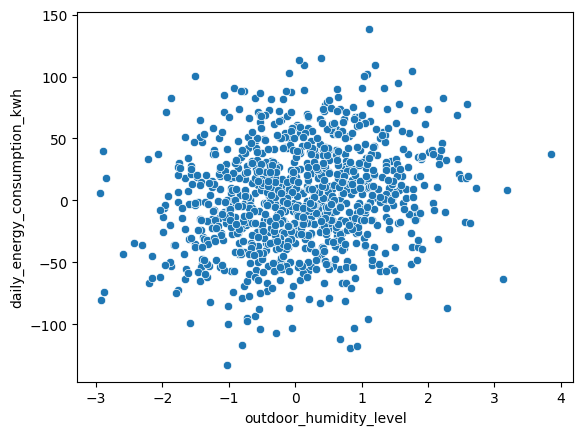

In [12]:
sns.scatterplot(x=df["outdoor_humidity_level"], y=df["daily_energy_consumption_kwh"])
plt.show()

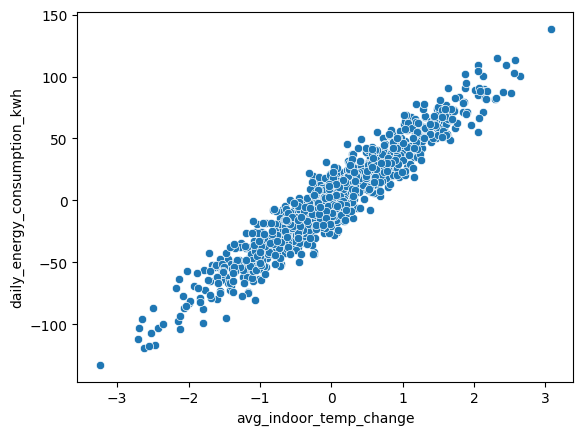

In [13]:
sns.scatterplot(x=df["avg_indoor_temp_change"], y=df["daily_energy_consumption_kwh"])
plt.show()

In [14]:
df.corr()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
avg_indoor_temp_change,1.000000,0.002584,0.956682
outdoor_humidity_level,0.002584,1.000000,0.169557
daily_energy_consumption_kwh,0.956682,0.169557,1.000000


In [15]:
from sklearn.model_selection import train_test_split
X=df.drop("daily_energy_consumption_kwh",axis=1)
y=df["daily_energy_consumption_kwh"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=34)

In [17]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [18]:
from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor(n_neighbors=5, algorithm="auto")
knn.fit(X_train_scaled,y_train)
y_pred=knn.predict(X_test_scaled)

In [22]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
print("R2 Score:", r2_score(y_pred, y_test))
print("Mean Squared Error:", mean_squared_error(y_pred, y_test))
print("Mean Absolute Error:", mean_absolute_error(y_pred, y_test))

R2 Score: 0.9191632613043085
Mean Squared Error: 126.33357133996019
Mean Absolute Error: 9.033060115649988


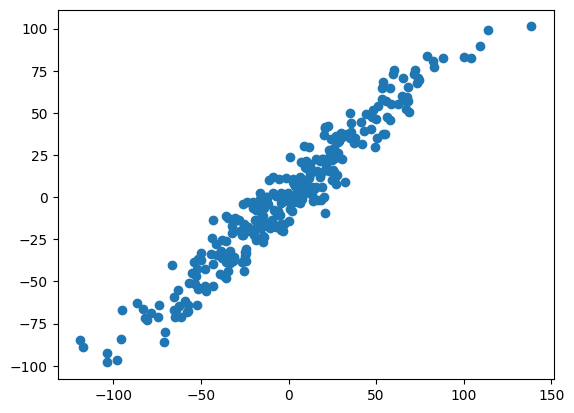

In [23]:
plt.scatter(y_test, y_pred)
plt.show()

In [24]:
knn2=KNeighborsRegressor(n_neighbors=7, algorithm="auto")
knn2.fit(X_train_scaled,y_train)
y_pred2=knn2.predict(X_test_scaled)

In [25]:
print("R2 Score:", r2_score(y_pred2, y_test))
print("Mean Squared Error:", mean_squared_error(y_pred2, y_test))
print("Mean Absolute Error:", mean_absolute_error(y_pred2, y_test))

R2 Score: 0.910474292358793
Mean Squared Error: 133.67003602679165
Mean Absolute Error: 9.131955440522606


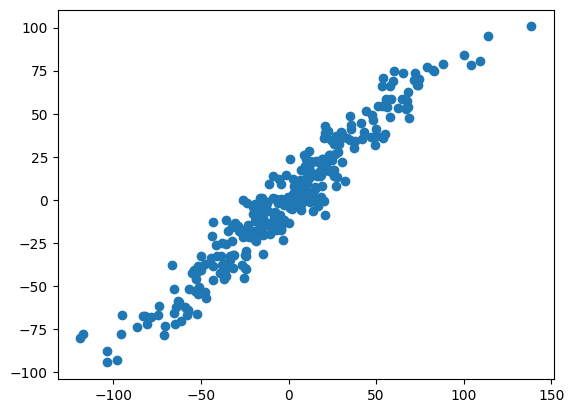

In [26]:
plt.scatter(y_test, y_pred2)
plt.show()